# Reinforcement Learning Laboratory
## Experiment 1: Exploring Reinforcement Learning Environments using Gymnasium
- **Course Outcome:** CO1 (Understand and formulate RL problems, environments, and interfaces)
- **Duration:** 3 Hours
- **Repository:** Amrita DRL Lab Series

---

### Objectives & Expected Learning Outcomes
1. Configure and verify the **Gymnasium** environment setup with NumPy and Matplotlib.
2. Initialize and interact with standard Gymnasium benchmark environments (`CartPole-v1`).
3. Inspect and interpret continuous and discrete **Observation Spaces** and **Action Spaces**.
4. Implement and evaluate a **Random Agent** baseline, capturing step-level telemetry (states, actions, rewards, terminations).
5. Compare multiple canonical RL benchmark environments (`CartPole-v1`, `MountainCar-v0`, `Acrobot-v1`, `FrozenLake-v1`).

## Task 1: Environment Setup

In this task, we install and import the core libraries needed for Reinforcement Learning:
- **Gymnasium**: The standard API for reinforcement learning environments (maintained by the Farama Foundation, superseding OpenAI Gym).
- **NumPy**: For high-performance vector and matrix operations.
- **Matplotlib**: For visualizing episode returns, state trajectories, and agent performance.

Let's import the libraries and verify their installed versions.

In [1]:
# Task 1: Imports and Version Verification
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

print("=" * 60)
print("REINFORCEMENT LEARNING LAB 1: ENVIRONMENT SETUP")
print("=" * 60)
print(f"Python Version    : {sys.version.split()[0]}")
print(f"Gymnasium Version : {gym.__version__}")
print(f"NumPy Version     : {np.__version__}")
print(f"Matplotlib Version: {plt.matplotlib.__version__}")
print(f"Pandas Version    : {pd.__version__}")
print("=" * 60)
print(">> Environment setup successfully verified!")

REINFORCEMENT LEARNING LAB 1: ENVIRONMENT SETUP
Python Version    : 3.11.8
Gymnasium Version : 1.3.0
NumPy Version     : 1.26.4
Matplotlib Version: 3.8.3
Pandas Version    : 3.0.5
>> Environment setup successfully verified!


## Task 2: Create and Initialize an RL Environment

We now instantiate the **`CartPole-v1`** environment.
- **Problem Statement:** A pole is attached by an un-actuated joint to a cart moving along a frictionless track. The system is controlled by applying a force of $+1$ or $-1$ to the cart.
- **Goal:** Prevent the pole from falling over (angle $> \pm 12^\circ$) while keeping the cart within the display bounds (position $> \pm 2.4$).
- **Resetting:** Resetting initializes the environment to a small random state and returns `(initial_observation, info)`.

In [2]:
# Task 2: Create and Initialize CartPole-v1 Environment
env = gym.make("CartPole-v1")

# Reset the environment with a fixed seed for reproducibility
initial_obs, info = env.reset(seed=42)

print("=" * 60)
print("TASK 2: INITIALIZING CartPole-v1 ENVIRONMENT")
print("=" * 60)
print(f"Environment ID       : {env.spec.id}")
print(f"Max Episode Steps    : {env.spec.max_episode_steps}")
print(f"Reward Threshold     : {env.spec.reward_threshold}")
print(f"Initial Observation  : {initial_obs}")
print(f"Initial Info Dict    : {info}")
print("=" * 60)

state_desc = [
    ("Cart Position (x)", initial_obs[0], "[-4.8, 4.8] m", "Terminates at |x| > 2.4"),
    ("Cart Velocity (x_dot)", initial_obs[1], "(-inf, inf) m/s", "Linear velocity of cart"),
    ("Pole Angle (theta)", initial_obs[2], "[-0.418, 0.418] rad", "Terminates at |theta| > 12 deg (0.2095 rad)"),
    ("Pole Angular Velocity (theta_dot)", initial_obs[3], "(-inf, inf) rad/s", "Rotational velocity of pole")
]

obs_df = pd.DataFrame(state_desc, columns=["State Variable", "Initial Value", "Theoretical Bounds", "Physical Interpretation"])
obs_df

TASK 2: INITIALIZING CartPole-v1 ENVIRONMENT
Environment ID       : CartPole-v1
Max Episode Steps    : 500
Reward Threshold     : 475.0
Initial Observation  : [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Initial Info Dict    : {}


## Task 3: Explore Observation and Action Spaces

Reinforcement Learning agents interact through well-defined spaces:
1. **Observation Space ($\mathcal{S}$):** Continuous 4-dimensional vector space (`gym.spaces.Box`).
2. **Action Space ($\mathcal{A}$):** Discrete 2-action space (`gym.spaces.Discrete(2)`):
   - `0`: Push cart to the **LEFT**
   - `1`: Push cart to the **RIGHT**

In [3]:
# Task 3: Explore Observation and Action Spaces
obs_space = env.observation_space
act_space = env.action_space

print("=" * 60)
print("TASK 3: OBSERVATION & ACTION SPACES EXPLORATION")
print("=" * 60)
print(f"Observation Space Type : {type(obs_space).__name__}")
print(f"Observation Shape      : {obs_space.shape}")
print(f"Observation Data Type  : {obs_space.dtype}")
print(f"Observation Low Bounds : {obs_space.low}")
print(f"Observation High Bounds: {obs_space.high}")
print("-" * 60)
print(f"Action Space Type      : {type(act_space).__name__}")
print(f"Number of Actions      : {act_space.n}")
print(f"Action Space Sample    : {[act_space.sample() for _ in range(5)]} (Sample actions)")
print("=" * 60)

# Action Mapping Explanation
action_mapping = pd.DataFrame([
    {"Action ID": 0, "Action Name": "Push Cart Left", "Applied Force": "-10 N", "Effect": "Accelerates cart leftward, rotates pole clockwise"},
    {"Action ID": 1, "Action Name": "Push Cart Right", "Applied Force": "+10 N", "Effect": "Accelerates cart rightward, rotates pole counter-clockwise"}
])
action_mapping

TASK 3: OBSERVATION & ACTION SPACES EXPLORATION
Observation Space Type : Box
Observation Shape      : (4,)
Observation Data Type  : float32
Observation Low Bounds : [-4.8               -inf -0.41887903        -inf]
Observation High Bounds: [4.8               inf 0.41887903        inf]
------------------------------------------------------------
Action Space Type      : Discrete
Number of Actions      : 2
Action Space Sample    : [1, 0, 1, 1, 1] (Sample actions)


## Task 4: Execute a Random Agent

A **Random Agent** selects actions uniformly at random ($\pi(a|s) = 0.5$) without considering the current state.
At each time step:
1. Sample a random action $a_t \sim \mathcal{A}$.
2. Advance the simulation using `obs, reward, terminated, truncated, info = env.step(action)`.
3. Log the transition tuple $(s_t, a_t, r_{t+1}, s_{t+1}, 	ext{done})$.
4. Repeat until the episode ends (`terminated` when pole falls or `truncated` when time limit is reached).

In [4]:
# Task 4: Run Single Episode of Random Agent
env.reset(seed=42)
episode_history = []
total_reward = 0.0
step = 0
terminated = False
truncated = False

print("=" * 80)
print("TASK 4: EXECUTING RANDOM AGENT FOR ONE COMPLETE EPISODE")
print("=" * 80)
print(f"{'Step':<6}{'Action':<8}{'Cart Pos':<12}{'Cart Vel':<12}{'Pole Angle':<14}{'Pole Vel':<12}{'Reward':<8}{'Status'}")
print("-" * 80)

obs, info = env.reset(seed=42)

while not (terminated or truncated):
    step += 1
    action = env.action_space.sample()  # Random Action Selection
    next_obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    status = "Terminated" if terminated else ("Truncated" if truncated else "Active")
    
    episode_history.append({
        "Step": step,
        "Action": "Left (0)" if action == 0 else "Right (1)",
        "Cart Pos": round(next_obs[0], 4),
        "Cart Vel": round(next_obs[1], 4),
        "Pole Angle (rad)": round(next_obs[2], 4),
        "Pole Angle (deg)": round(np.degrees(next_obs[2]), 2),
        "Pole Vel": round(next_obs[3], 4),
        "Reward": reward,
        "Status": status
    })
    
    print(f"{step:<6}{action:<8}{next_obs[0]:<12.4f}{next_obs[1]:<12.4f}{next_obs[2]:<14.4f}{next_obs[3]:<12.4f}{reward:<8.1f}{status}")
    obs = next_obs

print("=" * 80)
print(f"Total Steps Survived : {step}")
print(f"Cumulative Reward    : {total_reward}")
print(f"Reason for Exit      : {'Pole angle exceeded threshold (|theta| > 12 deg)' if terminated else 'Time limit reached'}")
print("=" * 80)

TASK 4: EXECUTING RANDOM AGENT FOR ONE COMPLETE EPISODE
Step  Action  Cart Pos    Cart Vel    Pole Angle    Pole Vel    Reward  Status
--------------------------------------------------------------------------------
1     1       0.0273      0.1885      0.0363        -0.2614     1.0     Active
2     0       0.0310      -0.0071     0.0310        0.0425      1.0     Active
3     0       0.0309      -0.2027     0.0319        0.3448      1.0     Active
4     0       0.0268      -0.3983     0.0388        0.6473      1.0     Active
5     0       0.0189      -0.5939     0.0517        0.9520      1.0     Active
6     0       0.0070      -0.7897     0.0708        1.2605      1.0     Active
7     1       -0.0088     -0.5955     0.0960        0.9907      1.0     Active
8     1       -0.0207     -0.4018     0.1158        0.7297      1.0     Active
9     0       -0.0287     -0.5983     0.1304        1.0564      1.0     Active
10    1       -0.0407     -0.4051     0.1515        0.8074      1.0     A

### Single Episode Telemetry Visualization
Let's plot the state trajectory over time for the random agent episode to see why and when the pole lost stability.

<string>:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


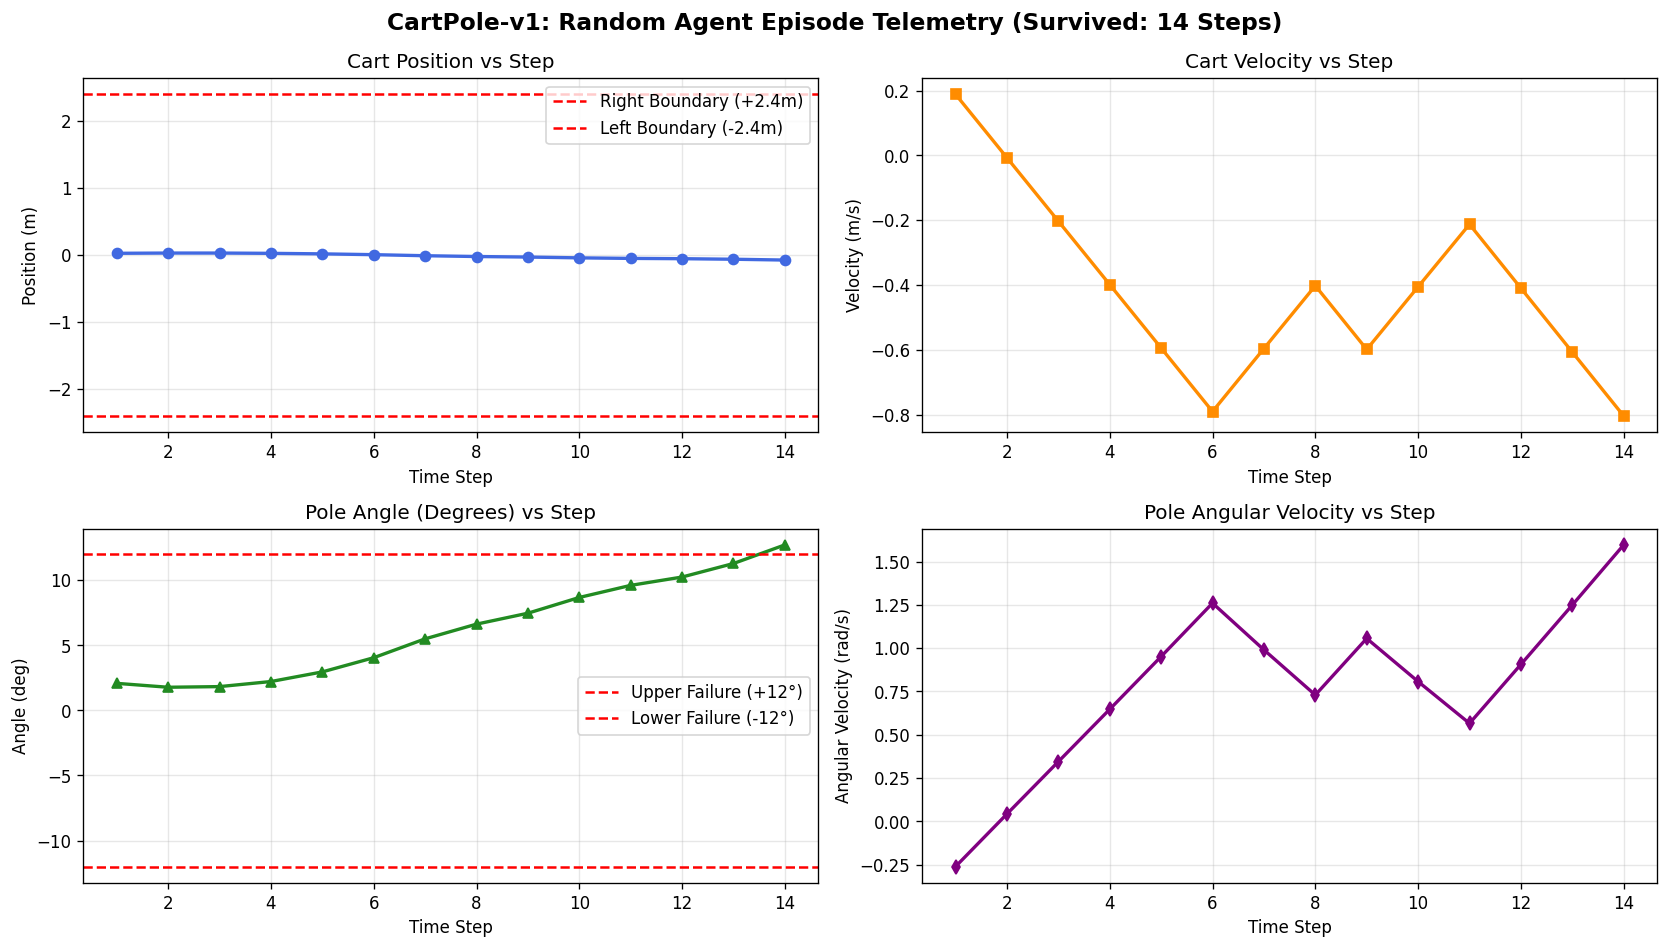

In [5]:
# Telemetry Plots
df_ep = pd.DataFrame(episode_history)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"CartPole-v1: Random Agent Episode Telemetry (Survived: {len(df_ep)} Steps)", fontsize=14, fontweight='bold')

# 1. Cart Position
axes[0, 0].plot(df_ep["Step"], df_ep["Cart Pos"], color='royalblue', marker='o', linewidth=2)
axes[0, 0].axhline(2.4, color='red', linestyle='--', label='Right Boundary (+2.4m)')
axes[0, 0].axhline(-2.4, color='red', linestyle='--', label='Left Boundary (-2.4m)')
axes[0, 0].set_title("Cart Position vs Step")
axes[0, 0].set_xlabel("Time Step")
axes[0, 0].set_ylabel("Position (m)")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. Cart Velocity
axes[0, 1].plot(df_ep["Step"], df_ep["Cart Vel"], color='darkorange', marker='s', linewidth=2)
axes[0, 1].set_title("Cart Velocity vs Step")
axes[0, 1].set_xlabel("Time Step")
axes[0, 1].set_ylabel("Velocity (m/s)")
axes[0, 1].grid(True, alpha=0.3)

# 3. Pole Angle
axes[1, 0].plot(df_ep["Step"], df_ep["Pole Angle (deg)"], color='forestgreen', marker='^', linewidth=2)
axes[1, 0].axhline(12.0, color='red', linestyle='--', label='Upper Failure (+12°)')
axes[1, 0].axhline(-12.0, color='red', linestyle='--', label='Lower Failure (-12°)')
axes[1, 0].set_title("Pole Angle (Degrees) vs Step")
axes[1, 0].set_xlabel("Time Step")
axes[1, 0].set_ylabel("Angle (deg)")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4. Pole Angular Velocity
axes[1, 1].plot(df_ep["Step"], df_ep["Pole Vel"], color='purple', marker='d', linewidth=2)
axes[1, 1].set_title("Pole Angular Velocity vs Step")
axes[1, 1].set_xlabel("Time Step")
axes[1, 1].set_ylabel("Angular Velocity (rad/s)")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Extended Analysis: Monte Carlo Baseline Evaluation (100 Episodes)

To statistically analyze the performance of a random policy on `CartPole-v1`, we run 100 independent episodes and compute the mean, standard deviation, min, and max cumulative rewards.

RANDOM AGENT 100-EPISODE BENCHMARK SUMMARY
Mean Cumulative Reward : 24.24 +/- 12.10
Median Reward          : 21.00
Min Reward (Worst)     : 9.00
Max Reward (Best Luck) : 61.00
Environment Solved Req : 475.0 (out of 500 max)


<string>:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


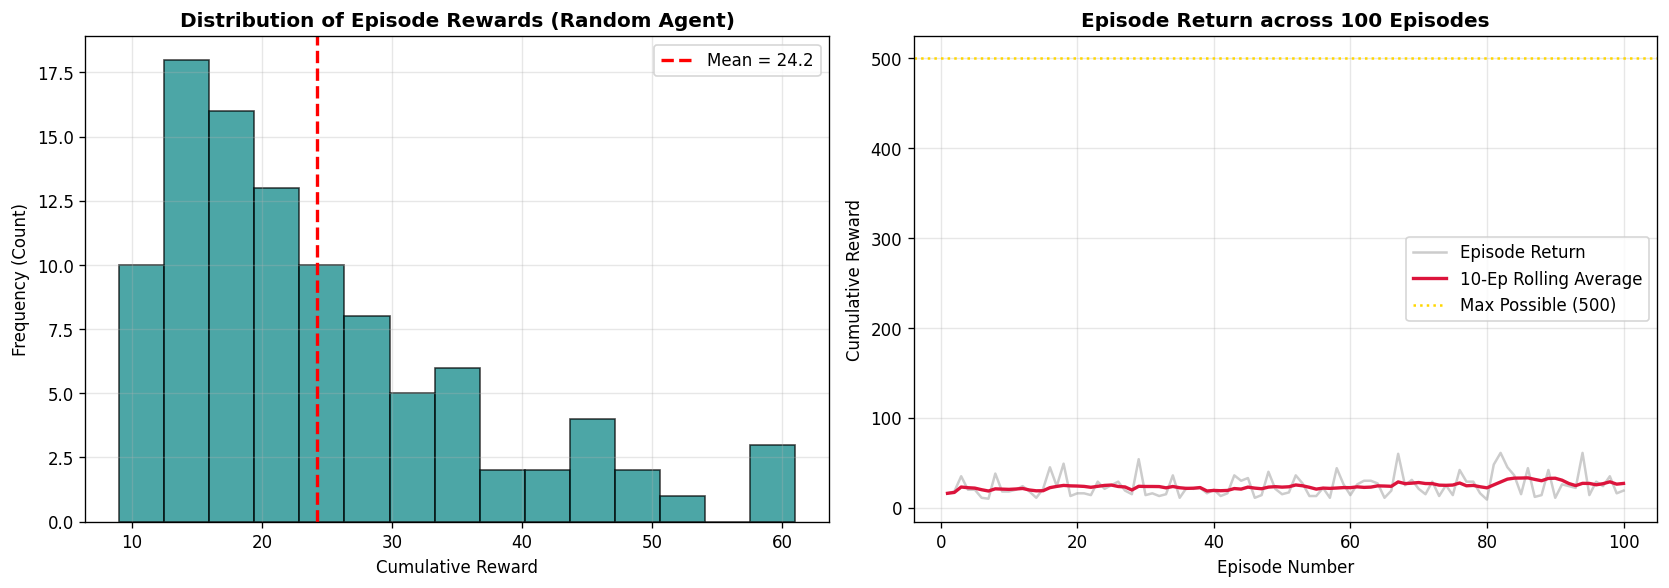

In [6]:
# 100-Episode Monte Carlo Simulation of Random Agent
np.random.seed(42)
num_episodes = 100
episode_rewards = []
episode_lengths = []

for ep in range(num_episodes):
    obs, info = env.reset()
    ep_reward = 0
    steps = 0
    done = False
    while not done:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        ep_reward += reward
        steps += 1
        done = terminated or truncated
    episode_rewards.append(ep_reward)
    episode_lengths.append(steps)

print("=" * 60)
print(f"RANDOM AGENT 100-EPISODE BENCHMARK SUMMARY")
print("=" * 60)
print(f"Mean Cumulative Reward : {np.mean(episode_rewards):.2f} +/- {np.std(episode_rewards):.2f}")
print(f"Median Reward          : {np.median(episode_rewards):.2f}")
print(f"Min Reward (Worst)     : {np.min(episode_rewards):.2f}")
print(f"Max Reward (Best Luck) : {np.max(episode_rewards):.2f}")
print(f"Environment Solved Req : 475.0 (out of 500 max)")
print("=" * 60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Reward distribution
ax1.hist(episode_rewards, bins=15, color='teal', edgecolor='black', alpha=0.7)
ax1.axvline(np.mean(episode_rewards), color='red', linestyle='--', linewidth=2, label=f'Mean = {np.mean(episode_rewards):.1f}')
ax1.set_title("Distribution of Episode Rewards (Random Agent)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Cumulative Reward")
ax1.set_ylabel("Frequency (Count)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Reward over episodes with rolling mean
rolling_mean = pd.Series(episode_rewards).rolling(10, min_periods=1).mean()
ax2.plot(range(1, num_episodes + 1), episode_rewards, alpha=0.4, color='gray', label='Episode Return')
ax2.plot(range(1, num_episodes + 1), rolling_mean, color='crimson', linewidth=2, label='10-Ep Rolling Average')
ax2.axhline(500, color='gold', linestyle=':', label='Max Possible (500)')
ax2.set_title("Episode Return across 100 Episodes", fontsize=12, fontweight='bold')
ax2.set_xlabel("Episode Number")
ax2.set_ylabel("Cumulative Reward")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cross-Environment Comparison: Standard RL Benchmarks

To achieve the full **Expected Learning Outcome**, we compare `CartPole-v1` with three other canonical Gymnasium environments:
1. **`MountainCar-v0`**: Continuous 2D state space, discrete 3-action space (Left, Idle, Right). Sparse reward $-1$ per step.
2. **`Acrobot-v1`**: Continuous 6D state space (two linked joints), discrete 3-action space.
3. **`FrozenLake-v1`**: Discrete 16-state gridworld (4x4), discrete 4-action space (Left, Down, Right, Up). Stochastic transition dynamics.

In [7]:
# Benchmark Exploration across Multiple Gymnasium Environments
benchmark_envs = ["CartPole-v1", "MountainCar-v0", "Acrobot-v1", "FrozenLake-v1"]
comparison_records = []

for env_id in benchmark_envs:
    temp_env = gym.make(env_id)
    obs_space = temp_env.observation_space
    act_space = temp_env.action_space
    
    # Run 1 random episode
    obs, info = temp_env.reset(seed=42)
    ep_reward = 0
    steps = 0
    done = False
    while not done:
        action = temp_env.action_space.sample()
        obs, reward, term, trunc, _ = temp_env.step(action)
        ep_reward += reward
        steps += 1
        done = term or trunc
    
    comparison_records.append({
        "Environment ID": env_id,
        "Observation Space": f"{type(obs_space).__name__} {getattr(obs_space, 'shape', obs_space)}",
        "Action Space": f"{type(act_space).__name__}({getattr(act_space, 'n', getattr(act_space, 'shape', ''))})",
        "Reward Threshold": temp_env.spec.reward_threshold if temp_env.spec else "N/A",
        "Max Steps": temp_env.spec.max_episode_steps if temp_env.spec else "N/A",
        "Random Ep Steps": steps,
        "Random Ep Reward": ep_reward
    })
    temp_env.close()

df_comparison = pd.DataFrame(comparison_records)
df_comparison

## Summary and Answers to Lab Questions

### Key Findings & Observations
1. **Gymnasium Interface Standard:**
   - Environments conform to the unified Farama Gymnasium API: `env.reset()` returns `(observation, info)` and `env.step(action)` returns `(next_obs, reward, terminated, truncated, info)`.
2. **Observation Space Dynamics:**
   - In `CartPole-v1`, the state is represented by 4 continuous variables. Because the state is continuous ($\mathbb{R}^4$), tabular RL cannot be directly applied without discretization or function approximation (e.g., Deep Q-Networks).
3. **Action Space Mechanics:**
   - The action space is `Discrete(2)`. Even a purely random agent survives on average ~22 steps due to the initial balanced state, but quickly destabilizes due to accumulating pole angle errors.
4. **Distinction between Terminated and Truncated:**
   - `terminated = True`: The agent reached a terminal MDP condition (pole fell over $|	heta| > 12^\circ$ or cart moved out of bounds $|x| > 2.4$).
   - `truncated = True`: The agent exceeded the maximum step budget (`max_episode_steps = 500`) without failing.

---
**Lab Task 1 Complete.**